# Deep Geometric Moment - Feature Visualization
This notebook loads a pretrained DGM model and visualizes the geometric moment features on ImageNet images.

In [17]:
import sys
sys.path.append('/scratch/sbeeredd/sandbox/Deep-Geometric-Moment')
print(f"Current working directory: {os.getcwd()}")
print(f"sys.path: {sys.path}")

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import torch.nn.functional as F


# Import the model from Deep-Geometric-Moment/
from resnet_gm import ResNet34

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Current working directory: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook
sys.path: ['/etc/python', '/home/sbeeredd/.conda/envs/myenv/lib/python311.zip', '/home/sbeeredd/.conda/envs/myenv/lib/python3.11', '/home/sbeeredd/.conda/envs/myenv/lib/python3.11/lib-dynload', '', '/home/sbeeredd/.conda/envs/myenv/lib/python3.11/site-packages', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment', '/tmp/tmpppitqty1', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment', '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment']
Imports successful!
PyTorch version: 2.9.0+cu128
CUDA available: True


## Configuration
Set paths for the model checkpoint and ImageNet dataset.

In [8]:
# Paths
dgm_model_path = '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment/checkpoints/res34_model_best.pth.tar'
data_root = '/scratch/sbeeredd/imagenet/ILSVRC/Data/CLS-LOC'

# Settings
num_images = 15  # Number of images to visualize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Model path: {dgm_model_path}")
print(f"Data root: {data_root}")
print(f"Device: {device}")
print(f"Model exists: {os.path.exists(dgm_model_path)}")
print(f"Data root exists: {os.path.exists(data_root)}")

Model path: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/checkpoints/res34_model_best.pth.tar
Data root: /scratch/sbeeredd/imagenet/ILSVRC/Data/CLS-LOC
Device: cuda
Model exists: True
Data root exists: True


## Load Pretrained Model
Load the ResNet34 model with geometric moment layers and the pretrained weights.

In [9]:
# Create model
model = ResNet34(device=device, num_classes=1000)
model = model.to(device)

# Load checkpoint
checkpoint = torch.load(dgm_model_path, map_location=device)
print(f"Checkpoint keys: {checkpoint.keys()}")

# Load state dict
if 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
    
    # Remove 'module.' prefix if present (from DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k  # remove 'module.' prefix
        new_state_dict[name] = v
    
    model.load_state_dict(new_state_dict)
    print(f"Loaded model from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Best accuracy: {checkpoint.get('best_acc', 'unknown')}")
else:
    state_dict = checkpoint
    # Remove 'module.' prefix if present
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict)
    
model.eval()
print("Model loaded successfully!")

/home/sbeeredd/.conda/envs/myenv/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Checkpoint keys: dict_keys(['epoch', 'state_dict', 'acc', 'best_acc', 'optimizer'])
Loaded model from epoch 99
Best accuracy: 75.638
Model loaded successfully!


## Prepare Data Transforms
Define transforms for ImageNet images (resize to 256x256, center crop to 224x224, normalize).

In [10]:
# ImageNet preprocessing - model expects EXACTLY 256x256 images
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Force resize to exactly 256x256
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

# For displaying original images
inverse_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

print("Transforms defined!")

Transforms defined!


## Load ImageNet Images
Collect sample images from the ImageNet validation set.

In [11]:
# Collect image paths from validation set
val_dir = os.path.join(data_root, 'val')
image_paths = []

# Walk through validation directories
for root, dirs, files in os.walk(val_dir):
    for file in files:
        if file.lower().endswith(('.jpeg', '.jpg', '.png')):
            image_paths.append(os.path.join(root, file))
            if len(image_paths) >= num_images:
                break
    if len(image_paths) >= num_images:
        break

print(f"Found {len(image_paths)} images")
if len(image_paths) > 0:
    print(f"First image: {image_paths[0]}")

Found 15 images
First image: /scratch/sbeeredd/imagenet/ILSVRC/Data/CLS-LOC/val/n02802426/ILSVRC2012_val_00038836.JPEG


## Run Inference and Extract Features
Run the DGM model on the images and extract the geometric moment visualizations.

In [14]:
results = []

with torch.no_grad():
    for img_path in image_paths[:num_images]:
        # Load and preprocess image
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        #image shape and type
        print(f"Processing image: {img_path}")
        print(f"Image size: {img.size}, Tensor shape: {img_tensor.shape}, Tensor type: {img_tensor.dtype}")
        print(f"Image tensor values: min={img_tensor.min()}, max={img_tensor.max()}, mean={img_tensor.mean()}")
        
        # Run inference with return_moments=True to get feature visualizations
        logits, moments, feature_map = model(img_tensor, return_moments=True)
        
        # Get prediction
        pred_class = logits.argmax(dim=1).item()
        
        # Store results
        results.append({
            'image_path': img_path,
            'image': img,
            'image_tensor': img_tensor.cpu(),
            'feature_map': feature_map.cpu(),
            'moments': (moments[0].cpu(), moments[1].cpu()),  # (grid, xy1)
            'prediction': pred_class,
            'logits': logits.cpu()
        })
        
print(f"Processed {len(results)} images")
print(f"Feature map shape: {results[0]['feature_map'].shape}")
print(f"Grid shape: {results[0]['moments'][0].shape}")
print(f"Moment vector shape: {results[0]['moments'][1].shape}")

Processing image: /scratch/sbeeredd/imagenet/ILSVRC/Data/CLS-LOC/val/n02802426/ILSVRC2012_val_00038836.JPEG
Image size: (500, 334), Tensor shape: torch.Size([1, 3, 256, 256]), Tensor type: torch.float32
Image tensor values: min=-2.1179039478302, max=2.640000104904175, mean=-0.4634835422039032
Processing image: /scratch/sbeeredd/imagenet/ILSVRC/Data/CLS-LOC/val/n02802426/ILSVRC2012_val_00010546.JPEG
Image size: (408, 500), Tensor shape: torch.Size([1, 3, 256, 256]), Tensor type: torch.float32
Image tensor values: min=-2.1179039478302, max=2.640000104904175, mean=-1.3079001903533936
Processing image: /scratch/sbeeredd/imagenet/ILSVRC/Data/CLS-LOC/val/n02802426/ILSVRC2012_val_00038899.JPEG
Image size: (388, 500), Tensor shape: torch.Size([1, 3, 256, 256]), Tensor type: torch.float32
Image tensor values: min=-2.1007792949676514, max=2.6225709915161133, mean=0.9774584174156189
Processing image: /scratch/sbeeredd/imagenet/ILSVRC/Data/CLS-LOC/val/n02802426/ILSVRC2012_val_00023152.JPEG
Image s

In [20]:
# checking what this does to  xy1 =  torch.flatten(F.avg_pool2d(grid, x.shape[2]), 1)
xy1 = results[0]['moments'][1]
print(f"Original xy1 shape: {xy1.shape}")
# use this avg pooling to get a single vector per image, then flatten it - the second argument to avg_pool2d is the kernel size, whic is x.shape[2], which should be the spatial dimensions of the grid (e.g., 8x8) to pool over the entire grid and get a single vector per image
avg_pooled = F.avg_pool2d(results[0]['moments'][0], kernel_size=results[0]['moments'][0].shape[2])
print(f"Avg pooled shape: {avg_pooled.shape}")
flattened_final = torch.flatten(avg_pooled, 1)
print(f"Flattened final shape: {flattened_final.shape}")


Original xy1 shape: torch.Size([1, 256])
Avg pooled shape: torch.Size([1, 256, 1, 1])
Flattened final shape: torch.Size([1, 256])


## Visualize Results
Display the original images alongside their geometric moment feature visualizations.

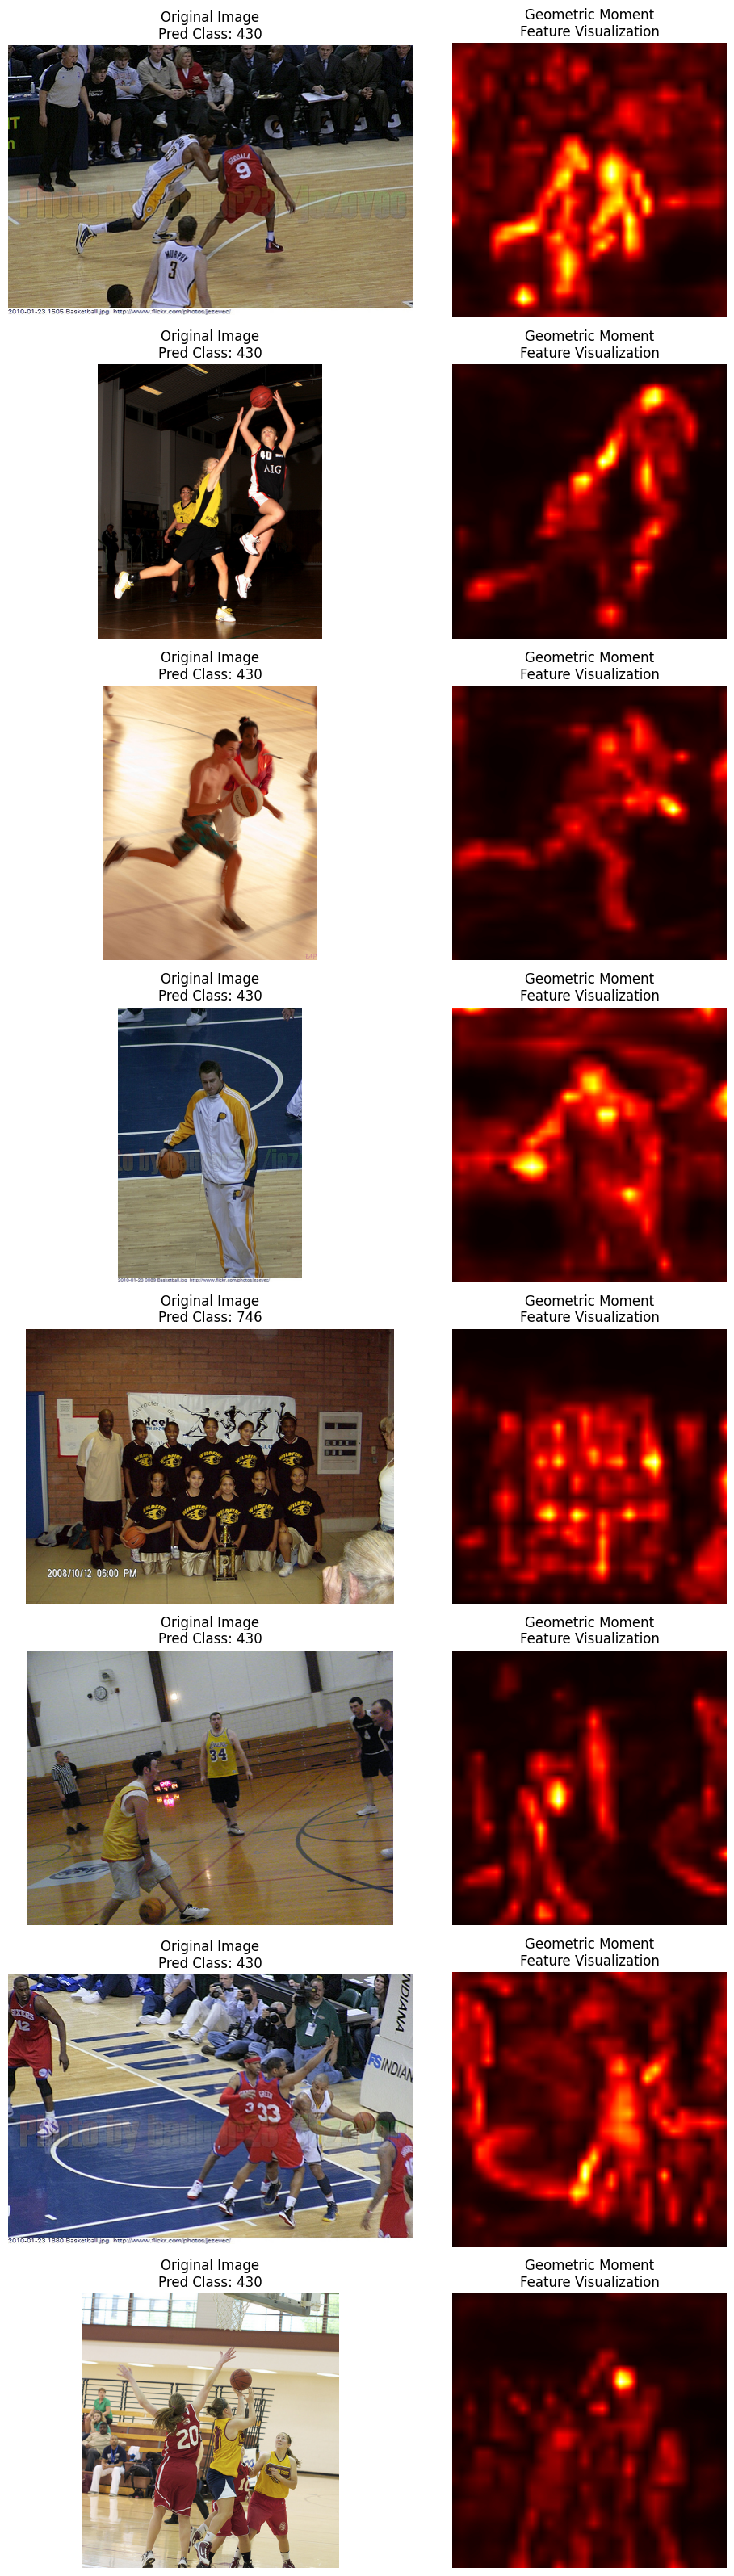

Displayed 8 image pairs


In [ ]:
def denormalize_image(img_tensor):
    """Denormalize image tensor for display"""
    img = inverse_normalize(img_tensor.squeeze(0))
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

# Create visualization
num_cols = 2
num_rows = min(len(results), 8)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, num_rows * 4))

if num_rows == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_rows):
    if idx >= len(results):
        break
        
    result = results[idx]
    
    # Original image
    axes[idx, 0].imshow(result['image'])
    axes[idx, 0].set_title(f'Original Image\nPred Class: {result["prediction"]}')
    axes[idx, 0].axis('off')
    
    # Feature visualization (geometric moment visualization)
    feature_vis = result['feature_map'].squeeze().numpy()
    axes[idx, 1].imshow(feature_vis, cmap='hot')
    axes[idx, 1].set_title('Geometric Moment\nFeature Visualization')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Displayed {num_rows} image pairs")

## Detailed Feature Map Analysis
Visualize individual channel responses in the geometric moment grid.

Grid shape: torch.Size([1, 256, 32, 32])
Number of feature channels: 256


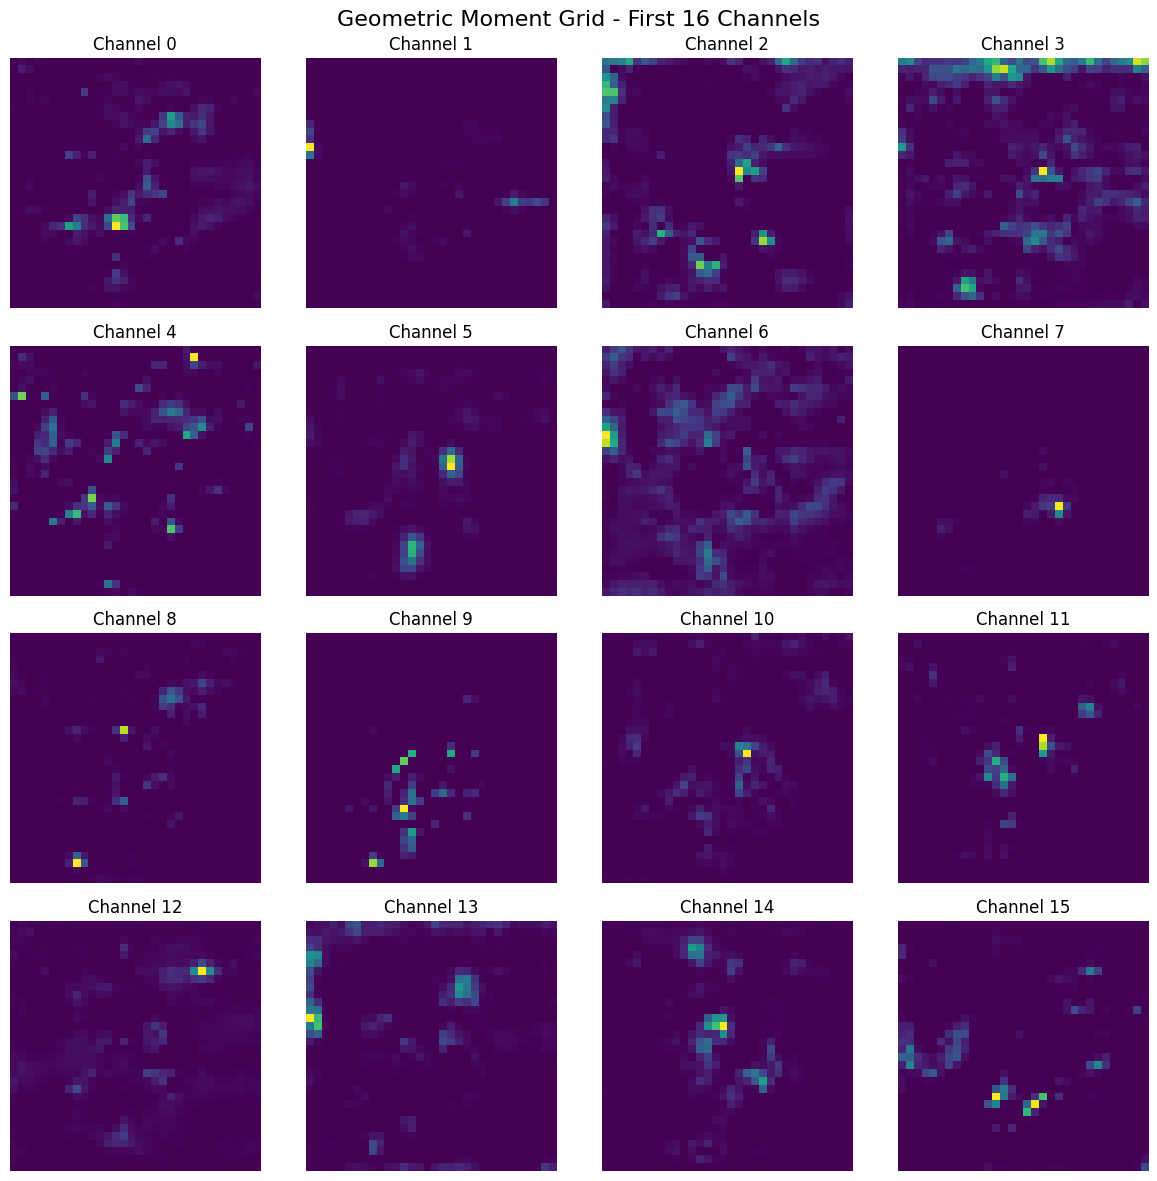

Moment vector (xy1) shape: torch.Size([1, 256])
Moment vector statistics - min: 0.0000, max: 15.1450, mean: 2.5076


In [ ]:
# Visualize grid features for the first image
if len(results) > 0:
    result = results[0]
    grid, xy1 = result['moments']
    
    print(f"Grid shape: {grid.shape}")
    print(f"Number of feature channels: {grid.shape[1]}")
    
    # Visualize first 16 channels
    num_channels_to_show = min(16, grid.shape[1])
    
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    for i in range(num_channels_to_show):
        channel_map = grid[0, i].numpy()
        axes[i].imshow(channel_map, cmap='viridis')
        axes[i].set_title(f'Channel {i}')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_channels_to_show, 16):
        axes[i].axis('off')
    
    plt.suptitle('Geometric Moment Grid - First 16 Channels', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"Moment vector (xy1) shape: {xy1.shape}")
    print(f"Moment vector statistics - min: {xy1.min():.4f}, max: {xy1.max():.4f}, mean: {xy1.mean():.4f}")

## Save Visualization Results
Save the visualizations to disk for later reference.

In [ ]:
# Create output directory
output_dir = '/scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations'
os.makedirs(output_dir, exist_ok=True)

# Save individual visualizations
for idx, result in enumerate(results[:5]):  # Save first 5
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original
    axes[0].imshow(result['image'])
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Feature map
    feature_vis = result['feature_map'].squeeze().numpy()
    im1 = axes[1].imshow(feature_vis, cmap='hot')
    axes[1].set_title('Geometric Moment Features')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Overlay
    denorm_img = denormalize_image(result['image_tensor'])
    axes[2].imshow(denorm_img)
    axes[2].imshow(feature_vis, cmap='hot', alpha=0.5)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.suptitle(f'Image {idx+1} - Predicted Class: {result["prediction"]}')
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, f'dgm_visualization_{idx+1}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"Saved: {save_path}")

print(f"\nAll visualizations saved to: {output_dir}")

Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_1.png
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_2.png
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_2.png
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_3.png
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_3.png
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_4.png
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_4.png
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations/dgm_visualization_5.png

All visualizations saved to: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizations
Saved: /scratch/sbeeredd/sandbox/Deep-Geometric-Moment/notebook/visualizat